In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
#1. load the climate data
df_climate = pd.read_csv('../data/raw/Coffee_Data_Set.csv')

In [10]:
df_climate['Country'] = df_climate['Location'].str.split('_').str[0]

In [11]:
df_climate['Temperature'] = (df_climate['Temp_Max'] + df_climate['Temp_Min'])/2

In [12]:
print("Extracted Countries:", df_climate['Country'].unique())
display(df_climate[['Date', 'Country', 'Temperature', 'Precipitation_mm']].head())

Extracted Countries: ['Brazil' 'China' 'Colombia' 'Ethiopia' 'Guatemala' 'Honduras' 'Mexico'
 'Peru']


,Date,Country,Temperature,Precipitation_mm
0,2000-01-03,Brazil,22.260,2.61
1,2000-01-03,Brazil,22.530,2.90
2,2000-01-03,Brazil,22.900,5.11
3,2000-01-03,Brazil,21.045,55.08
4,2000-01-03,Brazil,20.570,48.38


In [13]:
#1. Group the daily data by Year and Country
# We take the mean of the temperature and precipitation for the whole year.
climate_yearly = df_climate.groupby(['YEAR','Country'])[['Temperature','Precipitation_mm']].mean().reset_index()

#2. Rename 'YEAR' to 'Year' so it matches our other dataset perfectly
climate_yearly = climate_yearly.rename(columns={'YEAR':'Year'})

print('Yearly Climate Aggregation Complete:')
display(climate_yearly.head())

Yearly Climate Aggregation Complete:


,Year,Country,Temperature,Precipitation_mm
0,2000,Brazil,21.359274,3.771892
1,2000,China,18.909286,4.507747
2,2000,Colombia,19.979938,8.185755
3,2000,Ethiopia,20.826439,3.225618
4,2000,Guatemala,19.082051,3.754267


#### Now we will load the FAO Yield data

In [15]:
#1. load the fao yield data
df_fao = pd.read_csv('../data/raw/fao_coffee_yield.csv')

#2. rename 'Area' to 'Country' and 'Production.Yield' to 'Yield'

df_fao = df_fao.rename(columns={
    'Area':'Country',
    'Production.Yield':'Yield'
})

display(df_fao[['Country','Year','Yield']].head())

,Country,Year,Yield
0,Angola,1961,4817
1,Angola,1962,3700
2,Angola,1963,3366
3,Angola,1964,3964
4,Angola,1965,4100


##### Merging them together

In [16]:
# merge the two datasets together
# 'how=inner' means we only keep rows where both datasets have data for that specific country and year.
df_planet = pd.merge(climate_yearly, df_fao, on=['Year', 'Country'], how='inner')

print(f"Final Merged Dataset has {df_planet.shape[0]} rows.")

Final Merged Dataset has 184 rows.


##### Visualizing the result

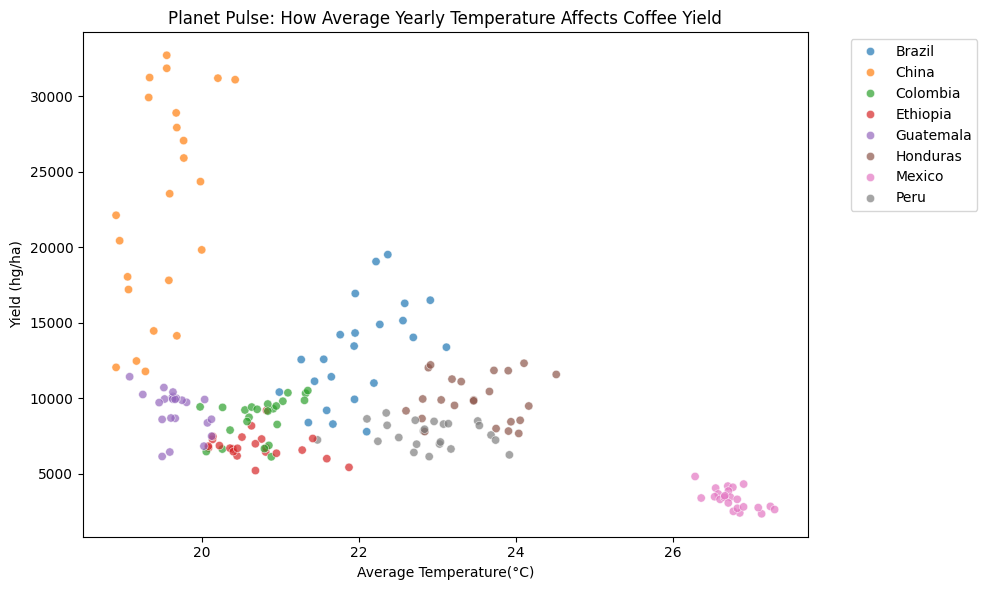

In [17]:
# visualize the result
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_planet, x='Temperature', y='Yield', hue='Country', alpha=0.7)
plt.title("Planet Pulse: How Average Yearly Temperature Affects Coffee Yield")
plt.xlabel("Average Temperature(°C)")
plt.ylabel("Yield (hg/ha)")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

In [18]:
# 3. Saving this clean, merged data for the Dash App
df_planet.to_csv('../data/processed/climate_yield.csv', index=False)

The Problem: Your Dash app cannot process 233,000 rows of daily weather instantly every time a user moves a slider. It would lag or crash.

The Solution: By doing this in the notebook first, we compressed 233,000 rows of daily data down to just a few hundred rows of yearly summaries mapped directly to crop yield.